<a href="https://colab.research.google.com/github/Clinton1029/Bostonhousing1/blob/main/Bostonhousing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Boston Housing Price Prediction Using Machine Learning

## Introduction

Predicting house prices is an important task in the real estate industry as it supports informed decision-making for buyers, sellers, and investors. House prices are influenced by factors such as crime rate, number of rooms, environmental conditions, accessibility, and neighborhood characteristics. In this project, the **Boston Housing Dataset** is used to develop a machine learning model that predicts the median value of owner-occupied homes (**MEDV**) based on 13 housing-related features.

---

## Problem Statement

Accurately estimating house prices is challenging because they are influenced by multiple factors. This project aims to develop a machine learning regression model that predicts the median value of homes using the Boston Housing Dataset. The model learns patterns from historical data to provide accurate house price predictions and identify the factors that influence property values.

# Project Workflow

The project will follow these steps:

1. Import Required Libraries
2. Load the Dataset
3. Exploratory Data Analysis (EDA)
4. Data Preprocessing and Preparation
5. Feature Selection
6. Split the Dataset into Training and Testing Sets
7. Choose the Machine Learning Model
8. Train the Machine Learning Model
9. Make Predictions
10. Evaluate Model Performance
11. Hyperparameter Tuning
12. Predict House Prices for New Data
13. Visualization of a Representative Decision Tree


## 1. Import Required Libraries

In [ ]:
# Import the Pandas library for data manipulation and analysis
import pandas as pd

# Import the Matplotlib library for creating visualizations
import matplotlib.pyplot as plt

# Import the Seaborn library for statistical data visualization
import seaborn as sns

# Import train_test_split to divide the dataset into training and testing sets
from sklearn.model_selection import train_test_split

# Import the plot_tree function for visualizing decision trees
from sklearn.tree import plot_tree

# Import the Random Forest Regressor algorithm
from sklearn.ensemble import RandomForestRegressor

# Import RandomizedSearchCV for random hyperparameter tuning
from sklearn.model_selection import RandomizedSearchCV

# Import GridSearchCV for exhaustive hyperparameter tuning
from sklearn.model_selection import GridSearchCV

# Import regression evaluation metrics
from sklearn.metrics import (
    mean_absolute_error,          # Calculates the average absolute prediction error
    mean_squared_error,           # Calculates the average squared prediction error
    r2_score                      # Measures the proportion of variance explained by the model
)





## 2. Load the Dataset

In [ ]:
# Load the dataset
df = pd.read_csv("/content/BostonHousing.csv")

## 3. Exploratory Data Analysis (EDA)

### 3.1 Display the first five rows

In [ ]:
# Display the first five rows
df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


### 3.2  Display the last five rows

In [ ]:
# Display the last five rows
df.tail()


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0
505,0.04741,0.0,11.93,0,0.573,6.030,80.8,2.5050,1,273,21.0,396.90,7.88,11.9


### 3.3 Display the shape of the dataset


In [ ]:
# Display the shape of the dataset
print("Dataset Shape:", df.shape)

Dataset Shape: (506, 14)


### 3.4 Display dataset information


In [ ]:
# Display dataset information
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       501 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  b        506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


### 3.5 Summary Statistics

In [ ]:
# Display summary statistics
df.describe()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
count,506.000000,506.000000,506.000000,506.000000,506.000000,501.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284341,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.705587,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.884000,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208000,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.625000,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


### 3.6 Distribution of the Target Variable (MEDV)


The distribution of the target variable (**MEDV**) is visualized using a histogram to examine how house prices are distributed across the dataset.

 This helps determine whether the target variable is normally distributed or exhibits skewness, which can influence the performance of regression models.

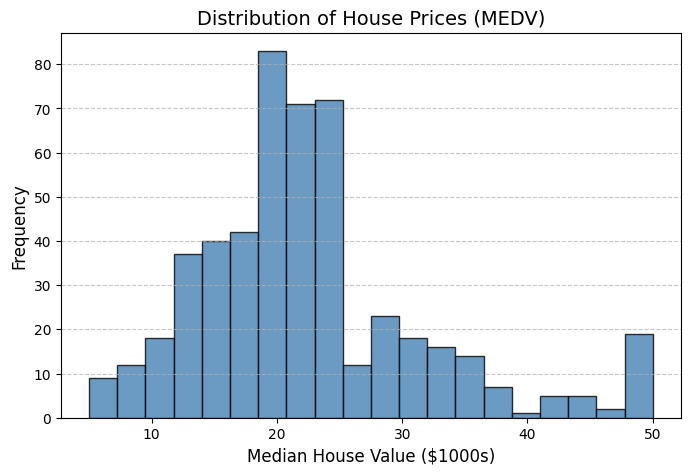

In [ ]:
plt.figure(figsize=(8, 5))

plt.hist(
    df["medv"],
    bins=20,
    color="steelblue",
    edgecolor="black",
    alpha=0.8
)

plt.title("Distribution of House Prices (MEDV)", fontsize=14)
plt.xlabel("Median House Value ($1000s)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.show()

###### Interpretation

The histogram shows that the **MEDV (Median House Value)** variable is concentrated between **\$15,000 and \$25,000**, indicating that most houses in the dataset fall within this price range. The distribution is **slightly right-skewed**, with relatively fewer houses having very high prices.



### 3.7 KDE (Kernel Density Estimation) Plots for Each Feature



Kernel Density Estimation (KDE) plots provide a smooth representation of the distribution of each numerical feature in the dataset.

Unlike histograms, KDE plots estimate the probability density of the data, making it easier to identify the shape of the distribution, detect skewness, observe multiple peaks (multimodality), and compare the spread of different variables.

These plots help in understanding the underlying distribution of each feature before building the machine learning model.

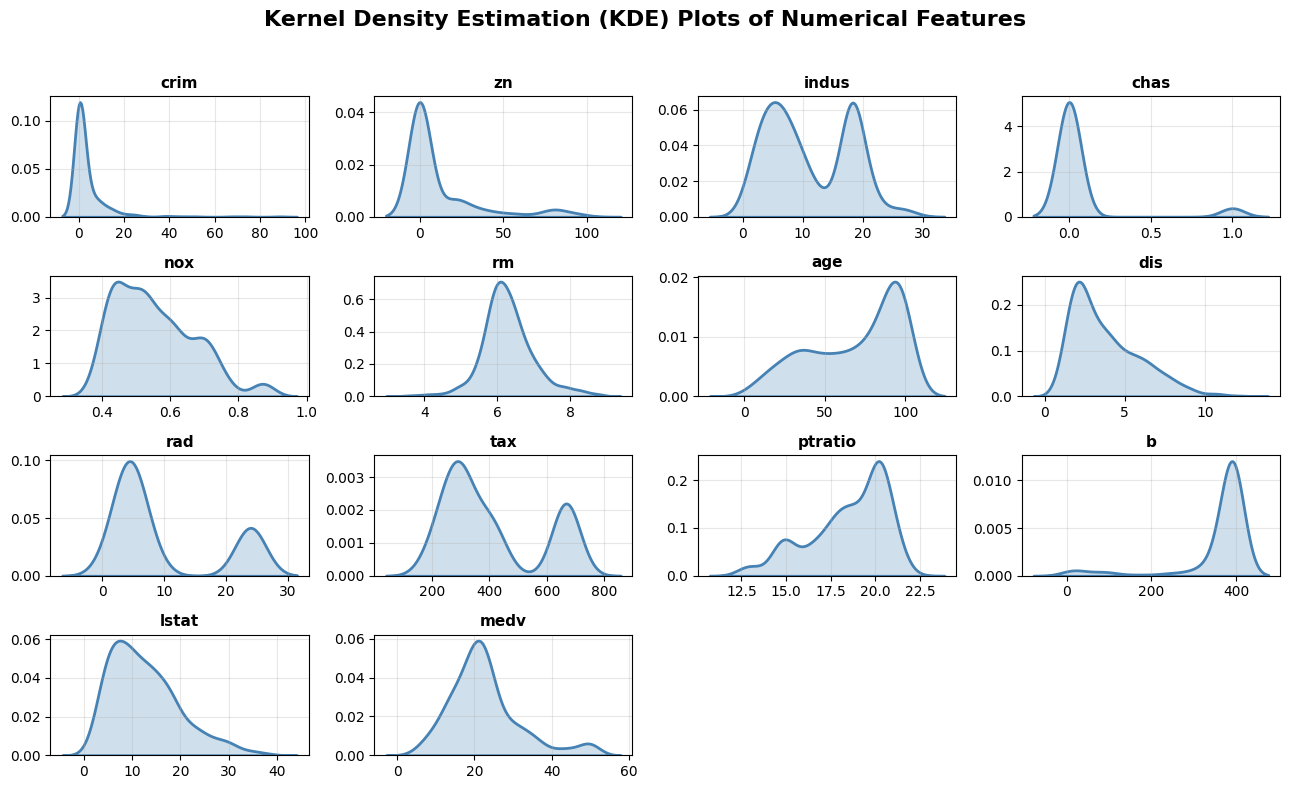

In [ ]:
fig, axes = plt.subplots(4, 4, figsize=(13, 8))

axes = axes.flatten()

for i, column in enumerate(df.columns):
    sns.kdeplot(
        data=df,
        x=column,
        fill=True,
        color="steelblue",
        linewidth=2,
        ax=axes[i]
    )

    axes[i].set_title(column, fontsize=11, fontweight="bold")
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")
    axes[i].grid(alpha=0.3)

# Remove any unused subplots
for j in range(len(df.columns), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle(
    "Kernel Density Estimation (KDE) Plots of Numerical Features",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

###### Interpretation

The KDE plots show the distribution of each numerical feature in the Boston Housing dataset.

 Most variables are **skewed** rather than normally distributed, indicating that observations are concentrated within specific ranges.

 Features such as **INDUS, RAD,** and **TAX** exhibit bimodal distributions, while **RM** is approximately normally distributed.

 The target variable (**MEDV**) is slightly right-skewed, with most house prices ranging between $15,000    and  $25,000 , and a noticeable peak at **$50,000**, reflecting the upper limit of house prices in the original dataset.

### 3.8 Boxplots

Boxplots are used to summarize the distribution of numerical features by displaying the median, quartiles, and potential outliers.

They provide a quick way to compare the spread and variability of different variables while identifying extreme values that may affect model performance.

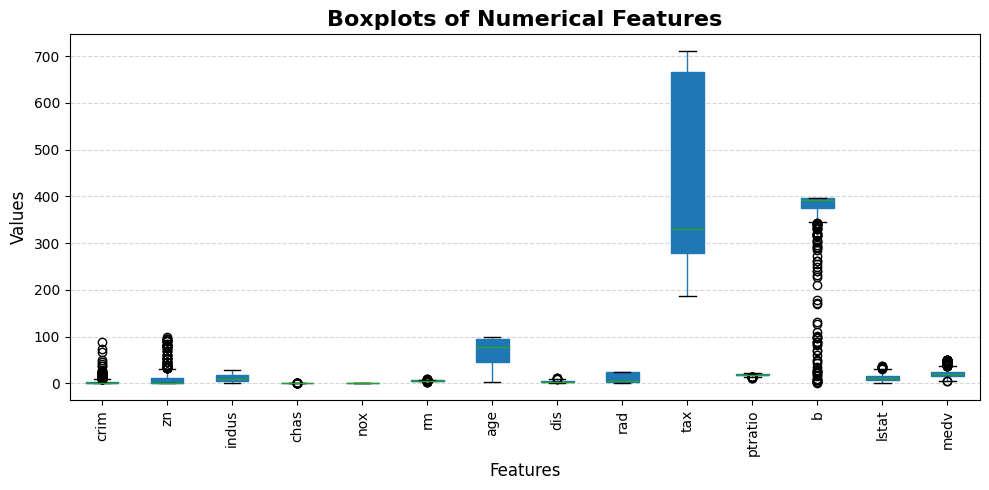

In [ ]:
plt.figure(figsize=(10, 5))

df.boxplot(
    rot=90,
    patch_artist=True,
    grid=False
)

plt.title(
    "Boxplots of Numerical Features",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Features", fontsize=12)
plt.ylabel("Values", fontsize=12)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

### Interpretation

The boxplots indicate that several numerical features contain **outliers**, particularly **CRIM, ZN, RM, DIS, B, LSTAT,** and **MEDV**, as shown by the individual points beyond the whiskers.

Features such as **TAX** and **AGE** exhibit a wide range of values, indicating high variability across observations.

In contrast, variables like **CHAS** and **NOX** have relatively small spreads.

 Overall, the presence of outliers and varying distributions suggests that some features may require preprocessing or careful consideration during model development.

### 3.9  Correlation Heatmap

A correlation heatmap illustrates the strength and direction of the relationships between numerical features. It helps identify highly correlated variables that may significantly influence the target variable or indicate multicollinearity.

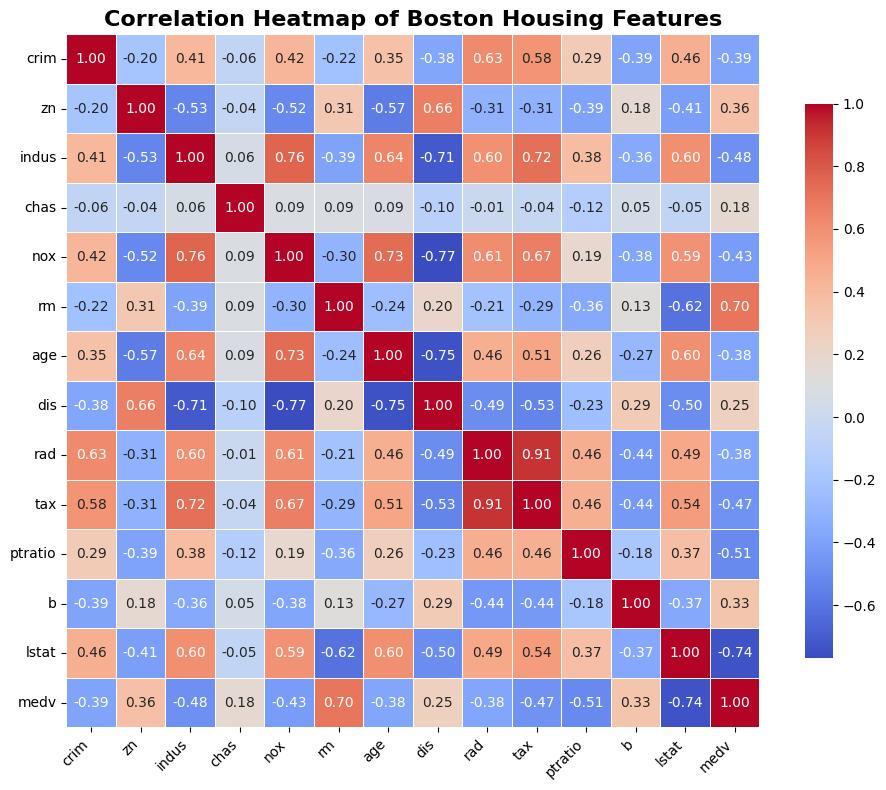

In [ ]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    df.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    linecolor="white",
    square=True,
    cbar_kws={"shrink": 0.8}
)

plt.title(
    "Correlation Heatmap of Boston Housing Features",
    fontsize=16,
    fontweight="bold"
)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

###### Interpretation

The correlation heatmap shows the strength and direction of the relationships between the features and the target variable (**MEDV**). Positive values indicate a direct relationship, while negative values indicate an inverse relationship.

- **RM** has the strongest positive correlation with **MEDV** (**0.70**), indicating that houses with more rooms generally have higher prices.
- **LSTAT** has the strongest negative correlation with **MEDV** (**-0.74**), suggesting that areas with a higher percentage of lower-status population tend to have lower house prices.
- **PTRATIO** (**-0.51**), **INDUS** (**-0.48**), **TAX** (**-0.47**), **NOX** (**-0.43**), and **CRIM** (**-0.39**) also show moderate negative correlations with house prices.
- **ZN** (**0.36**), **B** (**0.33**), **DIS** (**0.25**), and **CHAS** (**0.18**) have weak to moderate positive correlations with **MEDV**.
- Some predictor variables are highly correlated with each other, such as **RAD** and **TAX** (**0.91**), **NOX** and **DIS** (**-0.77**), and **INDUS** and **NOX** (**0.76**), indicating potential multicollinearity.

Overall, **RM** and **LSTAT** appear to be the most influential predictors of house prices, while several other features exhibit moderate relationships with the target variable.

# 4. Data Preprocessing and Preparation

Data preprocessing is an essential step in the machine learning pipeline that ensures the dataset is clean, consistent, and suitable for model training.

During this stage, missing values are handled, duplicate records are removed, data types are verified, outliers are handled and the dataset is prepared for the subsequent modeling process.

##4.1 Check Missing Values

In [ ]:
# Check for missing values
df.isnull().sum()

,0
crim,0
zn,0
indus,0
chas,0
nox,0
rm,5
age,0
dis,0
rad,0
tax,0


#### 4.1.2  Handling Missing Values in the RM Feature

The **RM** feature contains **5 missing values**.

Since it is a numerical variable, the missing values are replaced using the **median** of the feature.

The median is preferred because it is less affected by outliers and preserves the central tendency of the data.

In [ ]:
# Replace missing values with the median
df["rm"] = df["rm"].fillna(df["rm"].median())

# Verify that all missing values have been handled
print(df["rm"].isnull().sum())

0


### 4.2 Handling Duplicate Records

Duplicate records can introduce bias and affect the performance of the machine learning model.

 Therefore, the dataset is checked for duplicate entries and duplicates are removed if present.

In [ ]:
# Check duplicate records
df.duplicated().sum()

np.int64(0)

###### No duplicates in the Data

### 4.3 Verifying Data Types

The data types of all features are verified to ensure that numerical variables are stored in appropriate formats for analysis and model training.

In [ ]:
# Display data types
df.dtypes

,0
crim,float64
zn,float64
indus,float64
chas,int64
nox,float64
rm,float64
age,float64
dis,float64
rad,int64
tax,int64


###### Data types are correctly plaed

### 4.4 Handling Outliers

Outliers can have a significant impact on the performance of machine learning models.

 In this project, the **Interquartile Range (IQR)** method is used to identify and cap extreme values.

 Instead of removing observations, outliers are replaced with the lower and upper IQR limits to preserve the size of the dataset while reducing the influence of extreme values.

In [ ]:
# Handle outliers using the IQR method
df_outliers = df.copy()

for column in df_outliers.select_dtypes(include=["number"]).columns:
    Q1 = df_outliers[column].quantile(0.25)
    Q3 = df_outliers[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df_outliers[column] = df_outliers[column].clip(lower_bound, upper_bound)

# Use the dataset with capped outliers
df = df_outliers

print("Outliers have been handled successfully.")

Outliers have been handled successfully.


#### 4.4.1 Verify Outliers have been Handled

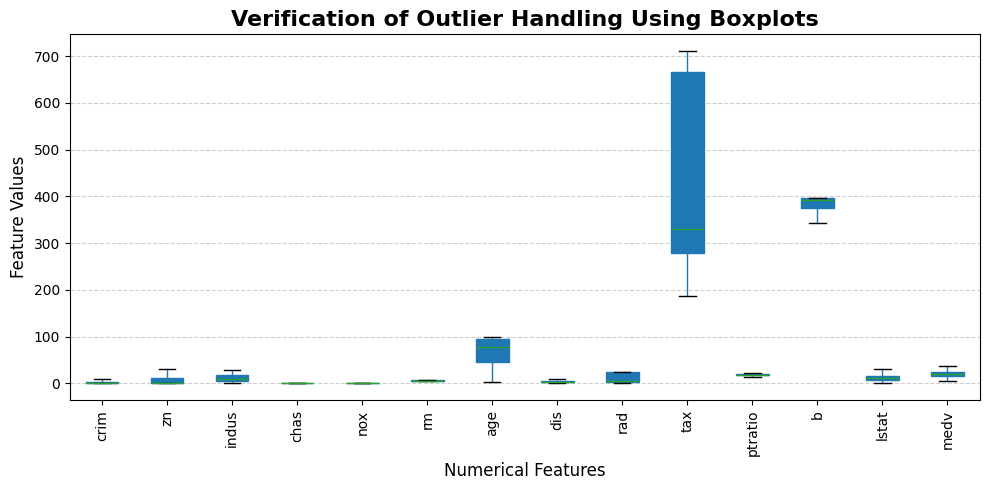

In [ ]:
plt.figure(figsize=(10, 5))

df.boxplot(
    rot=90,
    patch_artist=True,
    grid=False
)

plt.title(
    "Verification of Outlier Handling Using Boxplots",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Numerical Features", fontsize=12)
plt.ylabel("Feature Values", fontsize=12)

plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()

plt.show()

# 5. Feature Selection

Feature selection is the process of identifying the input variables (features) that will be used to train the machine learning model. In this project, **MEDV** is selected as the target variable since it represents the median value of owner-occupied homes. The remaining variables are used as predictor features to estimate house prices.

In [ ]:
# Select the predictor features
X = df[
    [
        "crim",
        "zn",
        "indus",
        "chas",
        "nox",
        "rm",
        "age",
        "dis",
        "rad",
        "tax",
        "ptratio",
        "b",
        "lstat"
    ]
]

# Select the target variable
y = df["medv"]

# Display the predictor features
print("Predictor Features (X):")
print(X.head())

# Display the target variable
print("\nTarget Variable (y):")
y.head()

Predictor Features (X):
      crim    zn  indus  chas    nox     rm   age     dis  rad  tax  ptratio  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222     18.7   

        b  lstat  
0  396.90   4.98  
1  396.90   9.14  
2  392.83   4.03  
3  394.63   2.94  
4  396.90   5.33  

Target Variable (y):


,medv
0,24.0
1,21.6
2,34.7
3,33.4
4,36.2


# 6. Split the Dataset into Training and Testing Sets

The dataset is divided into training and testing sets to evaluate the performance of the machine learning model on unseen data.

In this project, **80%** of the data is used for training the model, while the remaining **20%** is reserved for testing. A random state of **42** is used to ensure that the results are reproducible.

In [ ]:

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Display the shapes of the datasets
print("Training Features (X_train):", X_train.shape)
print("Testing Features (X_test):", X_test.shape)
print("Training Target (y_train):", y_train.shape)
print("Testing Target (y_test):", y_test.shape)

Training Features (X_train): (404, 13)
Testing Features (X_test): (102, 13)
Training Target (y_train): (404,)
Testing Target (y_test): (102,)


# 7. Choose the Machine Learning Model

The **Random Forest Regressor** is selected for this project because it is an ensemble learning algorithm that combines multiple decision trees to improve prediction accuracy and reduce overfitting.

 It is well-suited for regression problems, can model complex non-linear relationships, and is robust to outliers and noise.

 Additionally, Random Forest provides feature importance scores, making it useful for identifying the variables that have the greatest influence on house prices.

In [ ]:

# Create the Random Forest Regressor
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Display the model
print(model)

RandomForestRegressor(random_state=42)


# 8. Train the Machine Learning Model

The Random Forest Regressor is trained using the training dataset.

 During training, the model learns the relationship between the predictor features and the target variable, enabling it to make accurate predictions on unseen data.

In [ ]:
# Train the Random Forest Regressor
model.fit(X_train, y_train)

print("Model training completed successfully.")

Model training completed successfully.


# 9. Make Predictions

After training the Random Forest Regressor, the model is used to predict house prices for the testing dataset.

These predictions are then compared with the actual house prices to assess how well the model performs on unseen data.

In [ ]:
# Make predictions on the test set
y_pred = model.predict(X_test)

print("Predictions completed successfully.")

Predictions completed successfully.


#### 9.1 Compare Actual vs Predicted Values

In [ ]:
# Compare the actual and predicted values
predictions = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})

predictions.head(10)

,Actual Price,Predicted Price
0,23.6,23.331625
1,32.4,29.893625
2,13.6,16.482000
3,22.8,23.251000
4,16.1,16.472000
5,20.0,21.041000
6,17.8,19.432000
7,14.0,15.627000
8,19.6,21.131000
9,16.8,21.172000


# 10. Evaluate Model Performance

The performance of the Random Forest Regressor is evaluated using regression metrics.

Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and the R² Score are used to measure the accuracy of the model's predictions.

 Lower values of MAE, MSE, and RMSE indicate better predictive performance, while an R² score closer to 1 indicates that the model explains a larger proportion of the variance in house prices.

In [ ]:

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
mape = mean_absolute_percentage_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Display the results
print("Model Performance")
print("-" * 35)
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape * 100:.2f}%")
print(f"R² Score: {r2 * 100:.2f}%")

Model Performance
-----------------------------------
Mean Absolute Error (MAE): 1.82
Mean Squared Error (MSE): 6.01
Root Mean Squared Error (RMSE): 2.45
Mean Absolute Percentage Error (MAPE): 10.28%
R² Score: 87.71%


###### Interpretation

The evaluation metrics indicate that the Random Forest Regressor performs well in predicting house prices.

The **MAE (1.82)**, **MSE (6.01)**, and **RMSE (2.45)** show that the model has relatively low prediction errors.

The **MAPE of 10.28%** indicates that the model's predictions differ from the actual house prices by an average of **10.28%**.

 Furthermore, the **R² Score of 87.71%** shows that the model explains **87.71%** of the variation in house prices, demonstrating strong predictive accuracy and a good fit to the dataset.

# 11. Hyperparameter Tuning

Hyperparameter tuning is the process of optimizing the values of a machine learning model's hyperparameters to improve its predictive performance. Unlike model parameters, which are learned automatically during training, hyperparameters are defined before training and control how the model is built.

In this project, two hyperparameter tuning techniques are applied:

- **Randomized Search:** Randomly selects combinations of hyperparameter values from a predefined search space. It is computationally efficient and enables the exploration of a wide range of parameter combinations within a shorter time.

- **Grid Search:** Evaluates every possible combination of selected hyperparameter values to identify the optimal model. Although it requires more computational time, it provides a thorough search within the specified parameter grid.

The performance of the tuned models is then compared with that of the baseline Random Forest Regressor to determine whether hyperparameter tuning improves prediction accuracy.

## 11.1 Randomized Search

Randomized Search is used to identify a near-optimal combination of hyperparameters by randomly sampling from a predefined set of values.

 Compared to Grid Search, it is computationally more efficient because it evaluates only a limited number of randomly selected parameter combinations.

  The best hyperparameters obtained from this process are then used to build an improved Random Forest Regressor.

In [ ]:

# Define the hyperparameter search space
param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [None, 10, 20, 30, 40],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"],
    "bootstrap": [True, False]
}

# Create the Random Forest model
model1 = RandomForestRegressor(random_state=42)

# Perform Randomized Search
random_search = RandomizedSearchCV(
    estimator=model1,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring="r2",
    random_state=42,
    n_jobs=-1
)

# Train the model
random_search.fit(X_train, y_train)

RandomizedSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'bootstrap': [True, False],
                                        'max_depth': [None, 10, 20, 30, 40],
                                        'max_features': ['sqrt', 'log2'],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300, 500]},
                   random_state=42, scoring='r2')

## 11.1.1  Display the Best Hyperparameters

In [ ]:
print("Best Hyperparameters:")
print(random_search.best_params_)

Best Hyperparameters:
{'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 30, 'bootstrap': False}


### 11.1.2  Evaluate the Tuned Model

In [ ]:


# Best model from Randomized Search
best_random_model = random_search.best_estimator_

# Predictions
y_pred_random = best_random_model.predict(X_test)

# Evaluation metrics
mae = mean_absolute_error(y_test, y_pred_random)
mse = mean_squared_error(y_test, y_pred_random)
rmse = mse ** 0.5
mape = mean_absolute_percentage_error(y_test, y_pred_random)
r2 = r2_score(y_test, y_pred_random)

print("Randomized Search Performance")
print("-" * 35)
print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAPE : {mape * 100:.2f}%")
print(f"R²   : {r2 * 100:.2f}%")

Randomized Search Performance
-----------------------------------
MAE  : 1.78
MSE  : 5.35
RMSE : 2.31
MAPE : 9.92%
R²   : 89.07%


###### Interpretation

The Randomized Search successfully improved the performance of the Random Forest Regressor.

 The tuned model achieved a **Mean Absolute Error (MAE)** of **1.78**, a **Mean Squared Error (MSE)** of **5.35**, and a **Root Mean Squared Error (RMSE)** of **2.31**, indicating lower prediction errors than the baseline model.

 The **Mean Absolute Percentage Error (MAPE)** decreased to **9.92%**, while the **R² Score** increased to **89.07%**, showing that the tuned model explains a greater proportion of the variation in house prices. Overall, Randomized Search enhanced the model's predictive accuracy.

## 11.2 Grid Search

Grid Search is used to identify the optimal combination of hyperparameters by exhaustively evaluating every possible combination within a predefined parameter grid.

Although it requires more computational time than Randomized Search, it provides a comprehensive search and often yields the best-performing model.

 The optimal hyperparameters obtained from Grid Search are then used to train and evaluate the final Random Forest Regressor.

In [ ]:


# Define the parameter grid around the current best parameters
param_grid = {
    "n_estimators": [450,475, 500, 525,],
    "max_depth": [25, 30, 35],
    "min_samples_split": [2],
    "min_samples_leaf": [1, 2],
    "max_features": ["log2"],
    "max_leaf_nodes": [None, 100, 150],
    "bootstrap": [False]
}

# Create the Random Forest model
model2 = RandomForestRegressor(random_state=42)

# Perform Grid Search
grid_search = GridSearchCV(
    estimator=model2,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

# Train the model
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'bootstrap': [False], 'max_depth': [25, 30, 35],
                         'max_features': ['log2'],
                         'max_leaf_nodes': [None, 100, 150],
                         'min_samples_leaf': [1, 2], 'min_samples_split': [2],
                         'n_estimators': [450, 475, 500, 525]},
             scoring='r2')

### 11.2.1 Display the Best Hyperparameters

In [ ]:
print("Best Hyperparameters:")
print(grid_search.best_params_)

Best Hyperparameters:
{'bootstrap': False, 'max_depth': 25, 'max_features': 'log2', 'max_leaf_nodes': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 450}


### 11.2.2  Evaluate the Tuned Model

In [ ]:


# Best model from Grid Search
best_grid_model = grid_search.best_estimator_

# Make predictions
y_pred_grid = best_grid_model.predict(X_test)

# Evaluation metrics
mae = mean_absolute_error(y_test, y_pred_grid)
mse = mean_squared_error(y_test, y_pred_grid)
rmse = mse ** 0.5
mape = mean_absolute_percentage_error(y_test, y_pred_grid)
r2 = r2_score(y_test, y_pred_grid)

print("Grid Search Performance")
print("-" * 35)
print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAPE : {mape * 100:.2f}%")
print(f"R²   : {r2 * 100:.2f}%")

Grid Search Performance
-----------------------------------
MAE  : 1.77
MSE  : 5.33
RMSE : 2.31
MAPE : 9.91%
R²   : 89.11%


# 12. Model Comparison and Selection

The performance of the three Random Forest models is compared using the evaluation metrics obtained from the testing dataset.

 The model with the lowest prediction errors and the highest R² Score is selected as the final model for predicting house prices.

In [ ]:


# Compare the performance of all models
comparison = pd.DataFrame({
    "Model": [
        "Baseline Random Forest",
        "Random Forest (Randomized Search)",
        "Random Forest (Grid Search)"
    ],
    "MAE": [1.82, 1.78, 1.77],
    "MSE": [6.01, 5.35, 5.33],
    "RMSE": [2.45, 2.31, 2.31],
    "MAPE (%)": [10.28, 9.92, 9.91],
    "R² Score (%)": [87.71, 89.07, 89.11]
})

print(comparison)

# Select the best model based on the highest R² Score
best_model = comparison.loc[comparison["R² Score (%)"].idxmax()]

print("\nBest Model")
print("-" * 30)
print(best_model)

                               Model   MAE   MSE  RMSE  MAPE (%)  R² Score (%)
0             Baseline Random Forest  1.82  6.01  2.45     10.28         87.71
1  Random Forest (Randomized Search)  1.78  5.35  2.31      9.92         89.07
2        Random Forest (Grid Search)  1.77  5.33  2.31      9.91         89.11

Best Model
------------------------------
Model           Random Forest (Grid Search)
MAE                                    1.77
MSE                                    5.33
RMSE                                   2.31
MAPE (%)                               9.91
R² Score (%)                          89.11
Name: 2, dtype: object


###### Interpretation

The comparison shows that hyperparameter tuning improved the predictive performance of the Random Forest Regressor. The baseline model achieved an R² Score of **87.71%**, while the Randomized Search model improved the performance to **89.07%**.

The **Grid Search-tuned Random Forest** achieved the best overall performance with the **highest R² Score (89.11%)** and the **lowest prediction errors (MAE = 1.77, MSE = 5.33, RMSE = 2.31, and MAPE = 9.91%)**.

Therefore, the **Grid Search-tuned Random Forest Regressor** is selected as the final model for predicting house prices because it provides the highest predictive accuracy and the lowest prediction errors among the evaluated models.

# 12. Predict House Prices for New Data

After selecting the best-performing model, the Grid Search-tuned Random Forest Regressor is used to predict the median house value for new observations.

 This demonstrates the model's ability to estimate house prices based on the characteristics of a house and its surrounding environment.

In [ ]:


# New house data
new_house = pd.DataFrame({
    "crim": [0.025],
    "zn": [20],
    "indus": [5.50],
    "chas": [0],
    "nox": [0.45],
    "rm": [6.80],
    "age": [45],
    "dis": [5.20],
    "rad": [4],
    "tax": [200],
    "ptratio": [15.5],
    "b": [390.00],
    "lstat": [7.50]
})

# Predict the house price using the best model
predicted_price = best_grid_model.predict(new_house)

print(f"Predicted House Price: ${predicted_price[0] * 1000:.2f}")

Predicted House Price: $29868.76


###### Interpretation

The Grid Search-tuned Random Forest Regressor successfully predicted the house price for the new observation based on the provided housing characteristics.

 This demonstrates that the trained model can generalize to unseen data and can be used to estimate house prices for new properties.

# 13. Visualization of a Representative Decision Tree (4-Level Tree)

To understand how the Random Forest Regressor makes predictions, a **representative decision tree** from the trained model is visualized. Since the complete tree is very large and complex, only the **first four levels** are displayed. This provides a clear and readable illustration of the model's decision-making process while avoiding overcrowding.

Each node in the tree represents a decision based on one of the input features. The branches indicate the outcome of each decision, and the leaf nodes represent the predicted house values. The colors of the nodes reflect the distribution of the predicted values, making it easier to interpret how the model partitions the data.

Displaying a **4-level decision tree** provides a simplified view of the splitting process and demonstrates how the Random Forest learns relationships between the housing features and the target variable (**MEDV**).

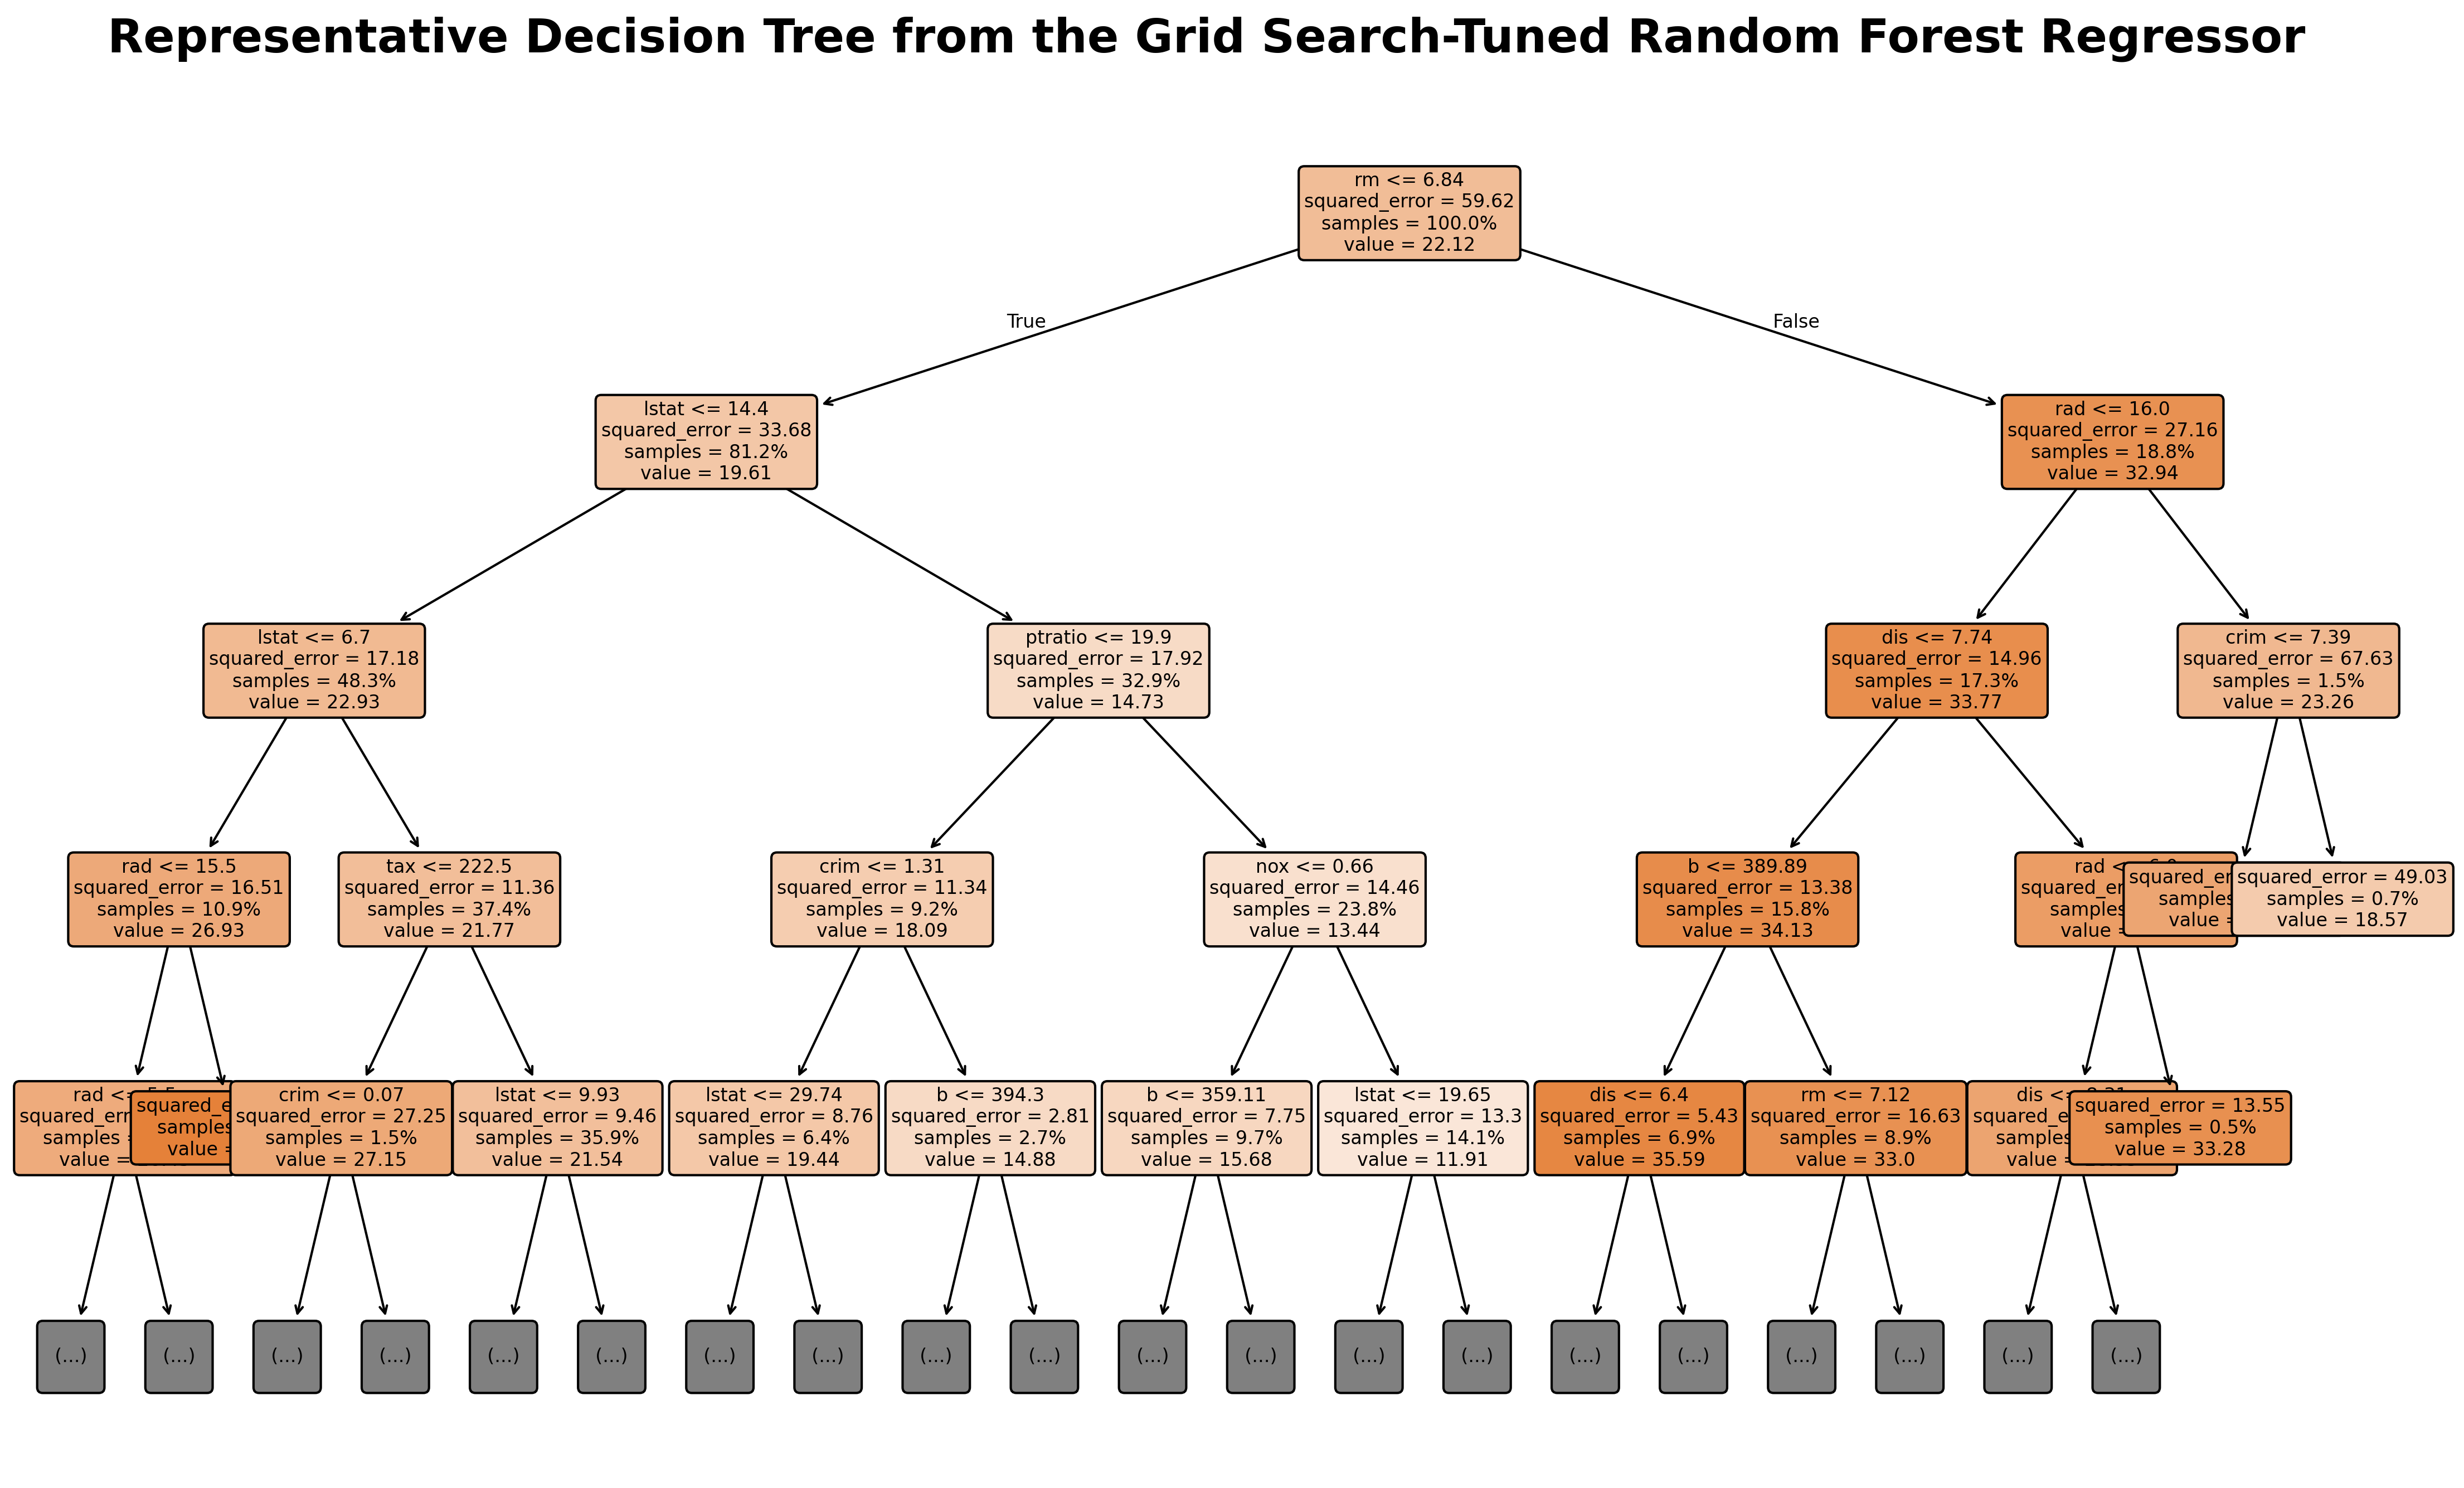

In [ ]:

# Create a high-quality figure
fig, ax = plt.subplots(figsize=(15, 9), dpi=300)

# Plot a representative decision tree from the Random Forest
plot_tree(
    decision_tree=best_grid_model.estimators_[0],
    feature_names=X.columns,
    filled=True,
    rounded=True,
    impurity=True,
    proportion=True,
    precision=2,
    max_depth=4,
    fontsize=8,
    ax=ax
)

# Add a professional title
ax.set_title(
    "Representative Decision Tree from the Grid Search-Tuned Random Forest Regressor",
    fontsize=20,
    fontweight="bold",
    pad=20
)

# Remove unnecessary axes
ax.set_axis_off()

# Adjust layout
plt.tight_layout()

# Display the figure
plt.show()

## Understanding the Dataset

The Boston Housing dataset contains information on housing and neighborhood characteristics collected from different suburbs of Boston. It consists of **13 input features** and **1 target variable (MEDV)**. The features describe various factors that influence house prices, while the target variable represents the **median value of owner-occupied homes** measured in thousands of U.S. dollars.

### Dataset Columns

| Column | Description |
|--------|-------------|
| **CRIM** | Per capita crime rate by town. Lower crime rates are generally associated with higher house prices. |
| **ZN** | Proportion of residential land zoned for large lots. Higher values indicate larger residential properties. |
| **INDUS** | Proportion of non-retail business acres per town. Higher values indicate more industrialized areas. |
| **CHAS** | Indicates whether the property borders the Charles River (1 = Yes, 0 = No). River-side properties may have higher values. |
| **NOX** | Nitric oxide concentration, representing the level of air pollution. Lower values indicate better air quality. |
| **RM** | Average number of rooms per dwelling. Houses with more rooms generally have higher market values. |
| **AGE** | Percentage of owner-occupied homes built before 1940. Higher values indicate older neighborhoods. |
| **DIS** | Weighted distance to major employment centers. Higher values indicate properties located farther from employment hubs. |
| **RAD** | Accessibility to radial highways. Higher values indicate better access to transportation networks. |
| **TAX** | Property tax rate per \$10,000. Higher tax rates may influence housing affordability. |
| **PTRATIO** | Pupil-to-teacher ratio in local schools. Lower ratios often indicate better educational resources. |
| **B** | Demographic variable included in the original dataset that may capture community characteristics. |
| **LSTAT** | Percentage of the population with lower socioeconomic status. Higher values are generally associated with lower house prices. |
| **MEDV** | **Target Variable:** Median value of owner-occupied homes, measured in thousands of U.S. dollars, which the model aims to predict. |